In [105]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [106]:
def padding(img, K_size):
    pad_size = K_size // 2
    padded_img = np.pad(img, ((pad_size, pad_size), (pad_size, pad_size)), mode='edge')
    return padded_img

### Erosion (侵蝕)

In [107]:
def manual_erosion(img, kernel):
    H, W = img.shape
    K_H, K_W = kernel.shape

    out = np.zeros((H, W), dtype=img.dtype)
    padded_img = padding(img, K_H)

    for i in range(H):
        for j in range(W):
            roi = padded_img[i : i + K_H, j : j + K_W]
            # 侵蝕 = 區域內的最小值 (Min)
            # 在二值影像中，只要有一個是0，最小值就是0
            valid_pixels = roi[kernel == 1]
            if len(valid_pixels) > 0:
                out[i, j] = np.min(valid_pixels)
            else:
                out[i, j] = 0

    return out

In [108]:
image = cv2.imread("")

### Dilation (膨脹)

In [109]:
def manual_dilation(img, kernel):
    H, W = img.shape
    K_H, K_W = kernel.shape

    out = np.zeros((H, W), dtype=img.dtype)
    padded_img = padding(img, K_H)

    for i in range(H):
        for j in range(W):

            roi = padded_img[i : i + K_H, j : j + K_W]
            # 膨脹 = 區域內的最大值 (Max)
            # 在二值影像中，只要有一個是1，最大值就是1
            valid_pixels = roi[kernel == 1]
            if len(valid_pixels) > 0:
                out[i, j] = np.max(valid_pixels)
            else:
                out[i, j] = 0

    return out

### 斷開

In [110]:
def manual_opening(img, kernel):
    eroded = manual_erosion(img, kernel)
    opened = manual_dilation(eroded, kernel)
    return opened

### 閉合

In [111]:
def manual_closing(img, kernel):
    dilated = manual_dilation(img, kernel)
    closed = manual_erosion(dilated, kernel)
    return closed

斷開+閉合用於降躁

Text(0.5, 1.0, 'opening')

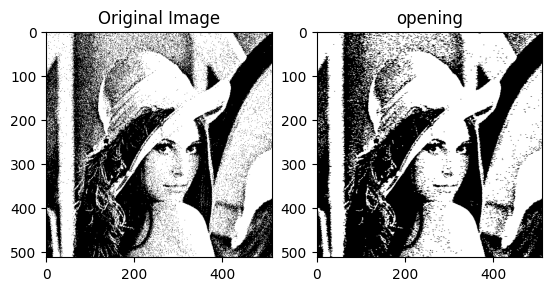

In [112]:
image = cv2.imread("/content/GaussianLenna.png", cv2.IMREAD_GRAYSCALE)

_, image = cv2.threshold(image, 125, 255, cv2.THRESH_BINARY)
#kernel = np.ones((3, 3), dtype=np.uint8)
kernel = np.array([[0, 0, 0],
                   [0, 1, 1],
                   [0, 0, 0]], dtype=np.uint8)

result_manual = manual_opening(image, kernel)
result_manual = manual_closing(result_manual, kernel)

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.subplot(1,2,2)
plt.imshow(result_manual, cmap='gray')
plt.title("opening")

### 形態學重建

步驟1.查看躁點圖片

In [113]:
import numpy as np
from skimage import io, img_as_float, img_as_ubyte
from skimage.draw import disk as draw_disk

# 讀取原圖
img = io.imread("/content/MRI_of_Human_Brain.jpg", as_gray=True)
img = img_as_float(img)

img_with_holes = img.copy()

# 設定要加入的暗洞位置 (row, col, radius)
# 請根據你的圖片大小和腦部位置調整這些座標
holes = [
    (1000, 400, 20),
    (600, 800, 20),
    (600, 700, 15),
    (450, 450, 15),
    (800, 450, 20),
    (1000, 900, 15),
    (1000, 800, 15),
    (800, 1000, 15),
    (500, 900, 15),
    (600, 600, 15)
]

# 加入暗洞
for row, col, radius in holes:
    rr, cc = draw_disk((row, col), radius, shape=img.shape)
    img_with_holes[rr, cc] = img_with_holes[rr, cc] * 0.1  # 變暗 75%

# 儲存
io.imsave('student_image_with_holes.png', img_as_ubyte(img_with_holes))
print("已儲存: student_image_with_holes.png")

已儲存: student_image_with_holes.png


In [114]:
img_with_holes.shape

(1534, 1433)

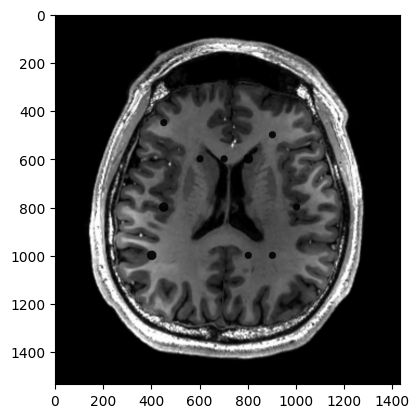

In [115]:
img = cv2.imread("/content/student_image_with_holes.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap="gray")

步驟2.膨脹

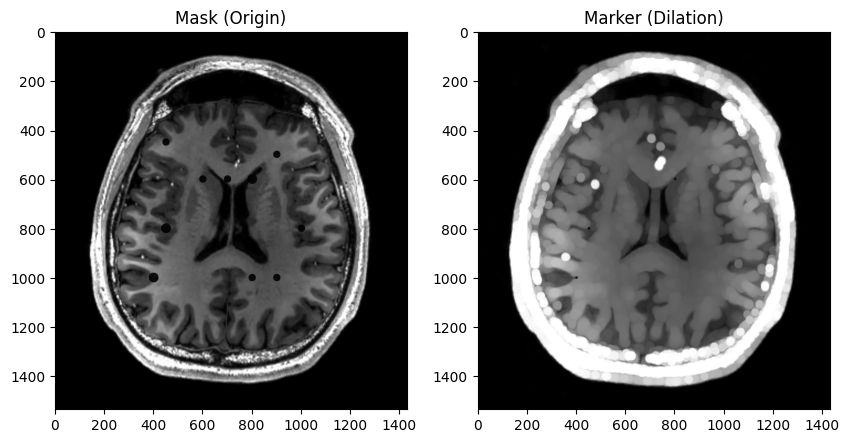

In [116]:
from skimage import io, img_as_ubyte, img_as_float
from skimage.morphology import dilation, disk, reconstruction
import matplotlib.pyplot as plt


img = io.imread("/content/student_image_with_holes.png", as_gray=True)
img = img_as_float(img)

selem = disk(15)
marker = dilation(img, selem)

cv2.imwrite("marker_for_student.png", img_as_ubyte(marker))
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title("Mask (Origin)")
plt.subplot(1,2, 2); plt.imshow(marker, cmap='gray'); plt.title("Marker (Dilation)")
plt.show()

步驟2.

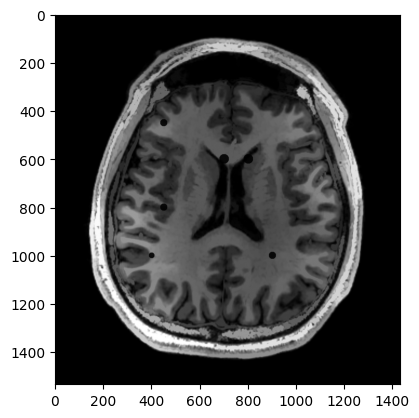

In [117]:
plt.imshow(opened,cmap="gray")

開始手動重建...
正在進行第 10 次迭代...
正在進行第 20 次迭代...
正在進行第 30 次迭代...
正在進行第 40 次迭代...
正在進行第 50 次迭代...
正在進行第 60 次迭代...
正在進行第 70 次迭代...
正在進行第 80 次迭代...
正在進行第 90 次迭代...
正在進行第 100 次迭代...
正在進行第 110 次迭代...
正在進行第 120 次迭代...
正在進行第 130 次迭代...
正在進行第 140 次迭代...
正在進行第 150 次迭代...
正在進行第 160 次迭代...
正在進行第 170 次迭代...
正在進行第 180 次迭代...
正在進行第 190 次迭代...
正在進行第 200 次迭代...
正在進行第 210 次迭代...
正在進行第 220 次迭代...
正在進行第 230 次迭代...
正在進行第 240 次迭代...
正在進行第 250 次迭代...
正在進行第 260 次迭代...
正在進行第 270 次迭代...
正在進行第 280 次迭代...
正在進行第 290 次迭代...
正在進行第 300 次迭代...
正在進行第 310 次迭代...
正在進行第 320 次迭代...
正在進行第 330 次迭代...
正在進行第 340 次迭代...
正在進行第 350 次迭代...
正在進行第 360 次迭代...
正在進行第 370 次迭代...
正在進行第 380 次迭代...
正在進行第 390 次迭代...
正在進行第 400 次迭代...
正在進行第 410 次迭代...
正在進行第 420 次迭代...
正在進行第 430 次迭代...
正在進行第 440 次迭代...
正在進行第 450 次迭代...
正在進行第 460 次迭代...
正在進行第 470 次迭代...
正在進行第 480 次迭代...
正在進行第 490 次迭代...
正在進行第 500 次迭代...
正在進行第 510 次迭代...
正在進行第 520 次迭代...
正在進行第 530 次迭代...
正在進行第 540 次迭代...
正在進行第 550 次迭代...
正在進行第 560 次迭代...
正在進行第 570 次迭代...
正在進行第 580 次迭代...
正在進行第 590 次迭代

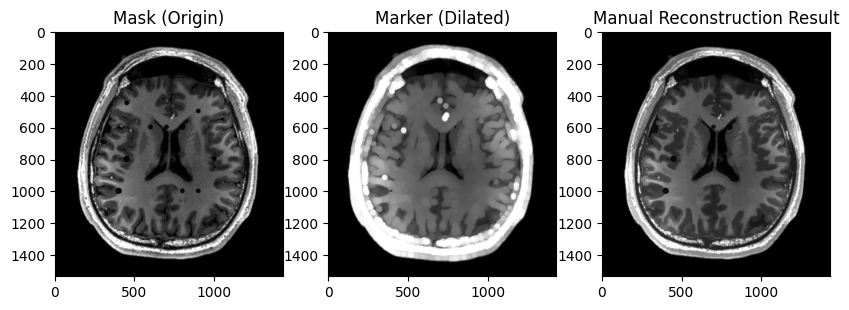

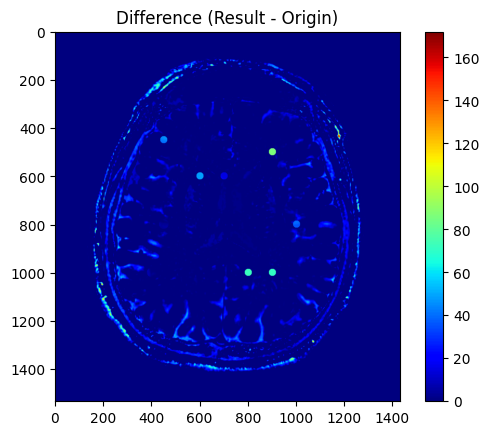

In [118]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import disk, erosion
from skimage import io, img_as_ubyte


mask = cv2.imread("/content/student_image_with_holes.png", cv2.IMREAD_GRAYSCALE)
marker = cv2.imread("/content/marker_for_student.png", cv2.IMREAD_GRAYSCALE)

# 轉成 0-1 的浮點數
mask = img_as_ubyte(mask)
marker = img_as_ubyte(marker)


def manual_reconstruction_erosion(marker, mask):
    current_marker = marker.copy()

    # 定義最基本的結構元素，上、下、左、右四連通
    selem = disk(1)

    iteration = 0
    while True:
        iteration += 1
        #1.腐蝕，讓marker高度開始降下
        eroded = erosion(current_marker, selem)

        #2.控制高度，不可小於mask
        reconstructed = np.maximum(eroded, mask)

        #3.檢查收斂，當值不在改變跳脫迴圈
        if np.array_equal(current_marker, reconstructed):
            print(f"演算法在第 {iteration} 次迭代後收斂停止。")
            break

        # 更新目前的影像，準備下一輪
        current_marker = reconstructed

        if iteration % 10 == 0:
            print(f"正在進行第 {iteration} 次迭代...")

    return current_marker


print("開始手動重建...")
result_manual = manual_reconstruction_erosion(marker, mask)

# 顯示結果
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1); plt.imshow(mask, cmap='gray'); plt.title("Mask (Origin)")

plt.subplot(1, 3, 2); plt.imshow(marker, cmap='gray'); plt.title("Marker (Dilated)")
plt.subplot(1, 3, 3); plt.imshow(result_manual, cmap='gray'); plt.title("Manual Reconstruction Result")
plt.show()

cv2.imwrite("Restruction.png", result_manual)

# 驗證差異
diff = result_manual - mask
plt.imshow(diff, cmap='jet')
plt.title("Difference (Result - Origin)")
plt.colorbar()
plt.show()